# 3. Images and catalogs

The workflow tools bundle a multi-step task into one call: resolve the name,
pick an archive from the archive notes, run the positional search. This
notebook uses them to find an image of M87, download and display it, and then
count and survey what the archives hold around the same position.

Requirements: `pip install manna-mcp matplotlib` and network access.

In [1]:
from fastmcp import Client

from manna.app import build_mcp

client = Client(build_mcp())
# client = Client("http://localhost:8000/mcp/")  # a server started with `python -m manna`


def payload(result):
    """The tool's JSON envelope. fastmcp exposes it as structured_content."""
    return result.structured_content


def as_dicts(envelope):
    """Inline table rows are positional lists; zip them with the column names."""
    names = [c["name"] for c in envelope["columns"]]
    return [dict(zip(names, row, strict=True)) for row in envelope["rows"]]

## Find images of a named target

`find_observations_of_target` with `service="image"` resolves the name, picks
the first archive with an image service, and runs the SIA query. The `plan`
field says what it chose and why; `truncated` says whether the inline cap cut
the list.

In [2]:
async with client:
    found = payload(
        await client.call_tool(
            "find_observations_of_target",
            {"target": "M87", "service": "image", "radius_deg": 0.05},
        )
    )

print("resolved:", found["resolved"])
print(
    "plan:",
    {k: found["plan"][k] for k in ("service", "chosen_archive", "endpoint", "alternatives")},
)
print("row_count:", found["row_count"], "| truncated:", found["truncated"])

images = as_dicts(found)
for row in images[:5]:
    print(
        row["obs_collection"],
        row["obs_bandpass"],
        row["access_format"],
        row["access_url"][:70] + "...",
    )

resolved: {'target': 'M87', 'ra': 187.70593077, 'dec': 12.39112325, 'frame': 'icrs'}
plan: {'service': 'image', 'chosen_archive': 'datalab', 'endpoint': 'https://datalab.noirlab.edu/sia/coadd_all', 'alternatives': ['alma', 'cadc']}
row_count: 43 | truncated: True
DECaLS DR5 z image/fits https://datalab.noirlab.edu/svc/cutout?col=ls_dr5&siaRef=legacysurvey-...
DECaLS DR5 r image/fits https://datalab.noirlab.edu/svc/cutout?col=ls_dr5&siaRef=legacysurvey-...
DECaLS DR5 g image/fits https://datalab.noirlab.edu/svc/cutout?col=ls_dr5&siaRef=legacysurvey-...
DECaLS DR5 r image/fits https://datalab.noirlab.edu/svc/cutout?col=ls_dr5&siaRef=legacysurvey-...
DECaLS DR5 z image/fits https://datalab.noirlab.edu/svc/cutout?col=ls_dr5&siaRef=legacysurvey-...


## Download one cutout and look at it

Each row's `access_url` is a cutout service call. Archives are not perfectly
reliable, so try candidates in order and keep the first one that returns a
FITS file. (At recording time the DECaLS DR8 cutouts worked and the DR5/DR7
ones returned HTTP 500.)

In [3]:
import io

import httpx
from astropy.io import fits

candidates = sorted(images, key=lambda r: r["obs_collection"], reverse=True)  # DR8 first
hdul = None
for row in candidates:
    resp = httpx.get(row["access_url"], timeout=120, follow_redirects=True)
    if resp.status_code == 200 and resp.headers.get("content-type", "").startswith("image/fits"):
        hdul = fits.open(io.BytesIO(resp.content))
        print(
            "using",
            row["obs_collection"],
            row["obs_bandpass"],
            "->",
            resp.status_code,
            len(resp.content),
            "bytes",
        )
        break
    print("skipped", row["obs_collection"], "->", resp.status_code)

hdul.info()

using DECaLS DR8 g DECam SDSS c0001 4720.0 1520.0 -> 200 1794240 bytes
Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     120   (687, 648)   float32   


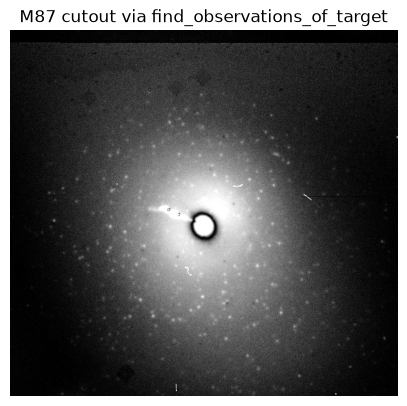

In [4]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

data = hdul[0].data
plt.figure(figsize=(5, 5))
plt.imshow(data, origin="lower", cmap="gray", norm=simple_norm(data, "asinh", percent=99))
plt.title("M87 cutout via find_observations_of_target")
plt.axis("off")
plt.show()

## A catalog cone search at the same position

`search_catalog_by_position` runs a Simple Cone Search against a catalog
service. Here the Gaia DR2 cone service at ARI Heidelberg, using the
coordinates the workflow tool already resolved.

In [5]:
ra, dec = found["resolved"]["ra"], found["resolved"]["dec"]

async with client:
    cone = payload(
        await client.call_tool(
            "search_catalog_by_position",
            {
                "endpoint": "https://gaia.ari.uni-heidelberg.de/cone/gaiadr2?",
                "ra": ra,
                "dec": dec,
                "radius_deg": 0.02,
            },
        )
    )

print("row_count:", cone["row_count"], "| truncated:", cone["truncated"])
print([c["name"] for c in cone["columns"]][:8], "...")

row_count: 34 | truncated: False
['source_id', 'designation', 'ra', 'dec', 'l', 'ecl_lon', 'ecl_lat', 'parallax'] ...


## How many observations are there?

`count_observations_near_target` resolves the name and runs a `COUNT(*)` at
the archive it picks. The `plan` shows the ADQL it ran, so the number is
reproducible.

In [6]:
async with client:
    count = payload(
        await client.call_tool(
            "count_observations_near_target", {"target": "M87", "radius_deg": 0.1}
        )
    )

print(count["count"], "rows within 0.1 deg at", count["plan"]["chosen_archive"])
print(count["plan"]["adql"])

4058 rows within 0.1 deg at datalab
SELECT COUNT(*) AS n FROM nsc_dr2.object WHERE q3c_radial_query(ra, dec, 187.70593077, 12.39112325, 0.1) = 't'


## Survey every archive at once

`survey_archives_for_target` asks each archive with notes what it holds near
the target. It is the slowest tool here (about a minute) because it fans out
to every archive.

In [7]:
async with client:
    survey = payload(
        await client.call_tool("survey_archives_for_target", {"target": "M87", "radius_deg": 0.1})
    )

print(survey["summary"])
for entry in survey["archives"]:
    line = f" - {entry['display_name']} [{entry['status']}]"
    if entry.get("count") is not None:
        line += f" count={entry['count']}"
    if entry.get("job_url"):
        line += f" job_url={entry['job_url']}"
    print(line)

{'archives_queried': 4, 'archives_with_data': 3, 'wavebands': ['millimeter', 'optical'], 'pending': 1, 'errors': 0}
 - NOIRLab Astro Data Lab [ok] count=4058
 - ALMA Science Archive [ok] count=132
 - ESO Science Archive [pending] job_url=https://archive.eso.org/tap_obs/async/f592e00b-9bab-4945-9e13-197f29d42733
 - ESA Gaia Archive [ok] count=310


Next: {doc}`04-archive-notes-and-errors` shows how archive notes reach a
client and what an error envelope looks like.